In [1]:
# MultiPhase AM Model Training with Animated Forecasting
%reload_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from model.AM import MultiPhaseAMModel
from dataset.AM_dataset import RowDataset, MultiPhaseDataset, row_collate_fn
from torch.utils.data import DataLoader

# Parameters
input_dim = 1
num_inducing_points = 10
num_latents = 2
num_outputs = 2
num_epochs = 300
plot_every = 10
device = "cuda:0"

# Load dataset
data_path = '/mnt/data/yiwang/code/RandomMaterial/clustered_grain/massive_05_testify_bilevel_sampling_2phases_with_clustered_grains'
material_dataset = MultiPhaseDataset(data_path, [512,512], n_phases=2)
row_dataset = RowDataset(material_dataset, rows_per_image=400)
row_loader = DataLoader(row_dataset, batch_size=400, shuffle=False, collate_fn=row_collate_fn)

loaders = iter(row_loader)
train_batch = next(loaders)
test_batch = next(loaders)

Y_train, labels_train = train_batch
X_train = torch.linspace(0, 1, Y_train.shape[1]).reshape(1, -1).repeat(Y_train.shape[0], 1)
Y_train.squeeze_()

Y_test, labels_test = test_batch
Y_test.squeeze_()
X_test = torch.linspace(0, 1, Y_test.shape[1]).reshape(1, -1).repeat(Y_test.shape[0], 1)

# Utility

def unpack_data_1d(X, Y, labels):
    x_list_by_class, y_list_by_class = [], []
    for label in [0, 1]:
        x_list = [x for x, l in zip(X, labels) if l == label]
        y_list = [y for y, l in zip(Y, labels) if l == label]
        x_list_by_class.append(torch.tensor(np.stack(x_list), dtype=torch.float32).unsqueeze(-1).to(device))
        y_list_by_class.append(torch.tensor(np.stack(y_list), dtype=torch.float32).unsqueeze(-1).to(device))
    return x_list_by_class, y_list_by_class

# Model & Optimizer
model = MultiPhaseAMModel(input_dim, num_inducing_points, num_latents, num_outputs, sigma_y=0.1).to(device)
x_list_by_class, y_list_by_class = unpack_data_1d(X_train, Y_train, labels_train)


# Forecast plot
def plot_forecast(X, Y, label=0):
    test_time = np.linspace(0, 1.0, 50, endpoint=False)
    with torch.no_grad():
        means, covars, S_ms = model.forecast(torch.tensor(test_time, dtype=torch.float32).to(device).unsqueeze(0))
        Sm = S_ms[label].detach().cpu().numpy()
        prior_mean = model.freq_model.gaussian_processes[label].variational_mean.squeeze().detach().cpu().numpy()
        mean = means[label].squeeze().detach().cpu().numpy()
        covar = covars[label].squeeze().detach().cpu().numpy()
    std = np.sqrt(np.diag(covar))

    fig, ax = plt.subplots()
    X = X[labels_train == label]
    Y = Y[labels_train == label]
    Y, _ = model.transmute(Y)
    Y = Y.detach().cpu().numpy()
    for i in range(min(10,X.shape[0])):
        ax.plot(test_time, Y[i], color='blue', lw=0.5, alpha=0.5)
    ax.plot(test_time, mean, color='red', lw=2, label='Mean prediction')
    ax.fill_between(test_time, mean + 2*std, mean - 2*std, color='red', alpha=0.2)
    ax.scatter(Sm, prior_mean, color='green', s=45, label='Most informative timestamps')
    ax.set_title(f'Forecast class {label}')

    ax.legend()
    return fig

# Classification

def classify(model, X_test, Y_test, L_test):
    model.eval()
    with torch.no_grad():
        #X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        #Y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)
        X_test = X_test.to(device)
        Y_test = Y_test.to(device)
        label_predict = model.predict(X_test, Y_test)
        correct = (label_predict.detach().cpu().numpy() == L_test).sum()

        accuracy = 100 * correct / len(L_test)
        print(f"ACC: {accuracy}%")
    model.train()
    return accuracy



In [2]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('./logs/debug/AM')

model = MultiPhaseAMModel(input_dim, num_inducing_points, num_latents, num_outputs, sigma_y=0.1).to(device)

x_list_by_class, y_list_by_class = unpack_data_1d(X_train, Y_train, labels_train)

# Training loop
num_epochs = 200
model.train()
# Optimizer
kernel_vars = [p for name, p in model.named_parameters() if 'kernel' in name]
encoding_vars = [p for name, p in model.named_parameters() if 'kernel' not in name]

from model.optimizers import SGLD, SGHMC
optimizer = torch.optim.Adam([
    {'params': kernel_vars, 'lr': 5e-3},
    {'params': encoding_vars, 'lr': 5e-2}
    ])
best_ACC = 0
num_iters = 1
for _ in range(num_iters):
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        # Compute loss
        loss = model.compute_loss(x_list_by_class, y_list_by_class, epoch=epoch)

        # Backward pass
        loss.backward()
        # nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)

        optimizer.step()

        if (epoch + 1) % 1 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.10f}")
            ACC = classify(model, X_test, Y_test, labels_test)
            best_ACC = max(ACC, best_ACC)
            if best_ACC == ACC:
                torch.save(model.state_dict(), "saved_models/am_test.pth")
            writer.add_scalar('training_loss', loss, epoch)
            writer.add_scalar('test_acc', ACC, epoch)
            writer.add_scalar('process_0_lengthscale', model.freq_model.gaussian_processes[0].kernel.lengthscale , epoch)
            writer.add_scalar('process_0_variance', model.freq_model.gaussian_processes[0].kernel.variance , epoch)
            writer.add_figure('check process 0', plot_forecast(X_test,Y_test,label=0), global_step=epoch)
            writer.add_figure('check process 1', plot_forecast(X_test,Y_test,label=1), global_step=epoch)

torch.save(model.state_dict(), "saved_models/am_test.pth")
print(best_ACC)

Epoch [1/500], Loss: -298.6264648438
ACC: 77.5%
Epoch [2/500], Loss: -300.4823608398
ACC: 51.0%
Epoch [3/500], Loss: -302.0236511230
ACC: 92.75%
Epoch [4/500], Loss: -303.1252136230
ACC: 84.25%
Epoch [5/500], Loss: -303.8719482422
ACC: 83.5%
Epoch [6/500], Loss: -304.4888305664
ACC: 92.25%
Epoch [7/500], Loss: -305.1540222168
ACC: 89.25%
Epoch [8/500], Loss: -305.7897644043
ACC: 87.75%
Epoch [9/500], Loss: -306.4319152832
ACC: 88.0%
Epoch [10/500], Loss: -307.0436706543
ACC: 88.0%
Epoch [11/500], Loss: -307.6693115234
ACC: 87.75%
Epoch [12/500], Loss: -308.3004150391
ACC: 87.75%
Epoch [13/500], Loss: -308.9602661133
ACC: 87.75%
Epoch [14/500], Loss: -309.5777587891
ACC: 87.75%
Epoch [15/500], Loss: -310.2097167969
ACC: 87.0%
Epoch [16/500], Loss: -310.8908996582
ACC: 87.25%
Epoch [17/500], Loss: -311.5662536621
ACC: 87.25%
Epoch [18/500], Loss: -312.2612609863
ACC: 86.75%
Epoch [19/500], Loss: -312.9500732422
ACC: 87.0%
Epoch [20/500], Loss: -313.6856384277
ACC: 87.0%
Epoch [21/500], L

/tmp/ipykernel_3067061/2528341011.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("saved_models/am_test.pth", map_location=device))


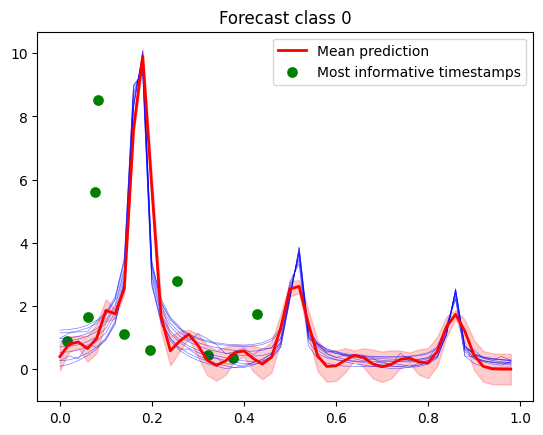

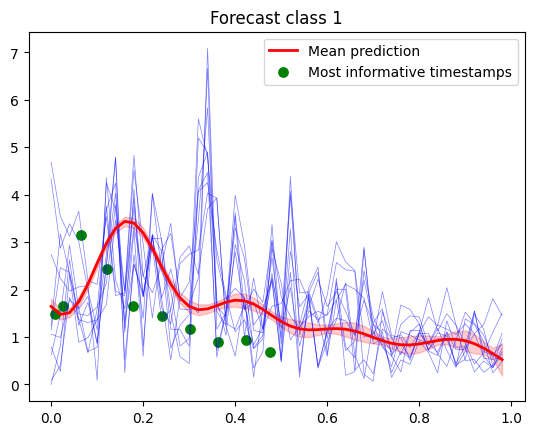

In [3]:
model.load_state_dict(torch.load("saved_models/am_test.pth", map_location=device))


plot_forecast(X_train.to(device),Y_train.to(device),label=0)
plot_forecast(X_train.to(device),Y_train.to(device),label=1)
plt.show()


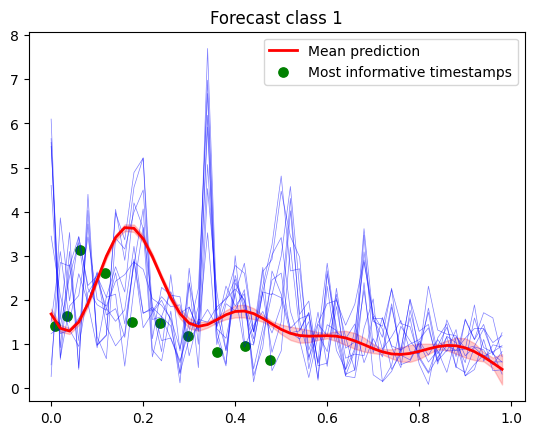

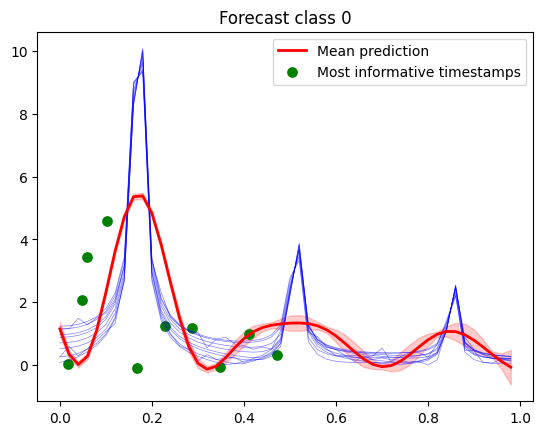

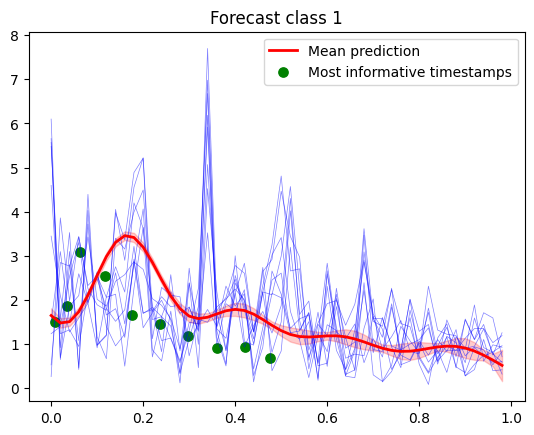

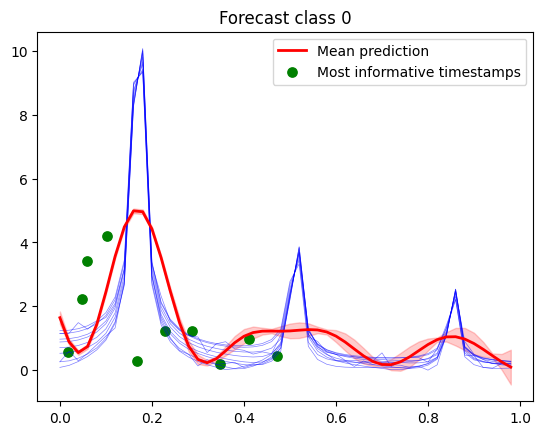

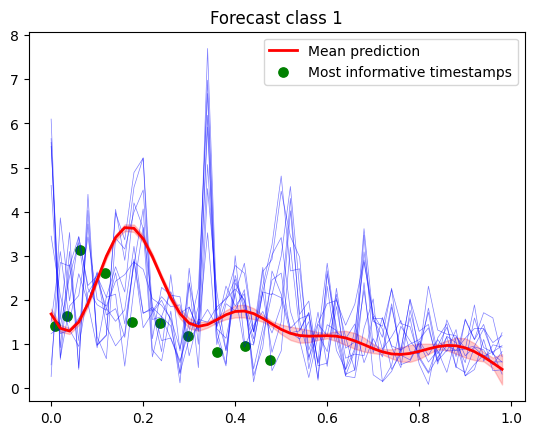

In [6]:
loaders = iter(row_loader)
test_batch = next(loaders)
test_batch = next(loaders)
test_batch = next(loaders)
test_batch = next(loaders)
test_batch = next(loaders)

Y_test, labels_test = test_batch
Y_test.squeeze_()
X_test = torch.linspace(0, 1, Y_test.shape[1]).reshape(1, -1).repeat(Y_test.shape[0], 1)

plot_forecast(X_test.to(device),Y_test.to(device),label=0)
plot_forecast(X_test.to(device),Y_test.to(device),label=1)

model.update_from_obs(X_test.to(device), Y_test.to(device))

plot_forecast(X_test.to(device),Y_test.to(device),label=0)
plot_forecast(X_test.to(device),Y_test.to(device),label=1)


###  Retrieving Model Parameters

In [7]:
def extract_model_parameters(model):
    """Extract key parameters from the trained model."""
    params = {
        'eta': {},  # Kernel parameters
        'z': {},    # Motion codes (latent vectors)
        'Lambda': {},  # Precision matrices
        'omega': {}    # Variational means
    }
    
    # Extract parameters for each GP in the frequency model
    for idx, gp in enumerate(model.freq_model.gaussian_processes):
        # Kernel parameters (eta)
        params['eta'][f'process_{idx}'] = {
            'lengthscale': gp.kernel.lengthscale.detach().cpu().numpy(),
            'variance': gp.kernel.variance.detach().cpu().numpy()
        }
        
        # Motion codes (z)
        params['z'][f'process_{idx}'] = gp.z.detach().cpu().numpy()
        
        # Precision matrix (Lambda)
        params['Lambda'][f'process_{idx}'] = gp.precision_covar.detach().cpu().numpy()
        
        # Variational mean (omega)
        params['omega'][f'process_{idx}'] = gp.variational_mean.detach().cpu().numpy()
    
    return params

In [8]:
model_params = extract_model_parameters(model)

print("Kernel parameters (eta):")
for process, params in model_params['eta'].items():
    print(f"  {process}: lengthscale={params['lengthscale']:.4f}, variance={params['variance']:.4f}")

print("\nMotion codes (z):")
for process, z in model_params['z'].items():
    print(f"  {process}: {z}")

Kernel parameters (eta):
  process_0: lengthscale=0.0537, variance=1.0705
  process_1: lengthscale=0.0621, variance=1.5722

Motion codes (z):
  process_0: [0.5412656 0.6994795]
  process_1: [0.3082193 0.2844071]


In [16]:
def plot_inducing_points(model):
    """Plot the most informative timestamps for each process."""
    fig, axs = plt.subplots(1, model.num_outputs, figsize=(16, 5))
    
    for idx, gp in enumerate(model.freq_model.gaussian_processes):
        # Get inducing points
        S_m = gp.get_inducing_points().detach().cpu().numpy()
        print(gp.variational_mean.shape)
        # Plot
        if model.num_outputs > 1:
            ax = axs[idx]
        else:
            ax = axs
            
        ax.stem(range(len(S_m)), S_m.flatten(), linefmt='g-', markerfmt='go', basefmt='k-', label='Inducing points')
        ax.set_title(f'Process {idx} - Most Informative Timestamps')
        ax.set_xlabel('Index')
        ax.set_ylabel('Frequency')
    
    plt.tight_layout()
    return fig

torch.Size([10, 1])
torch.Size([10, 1])


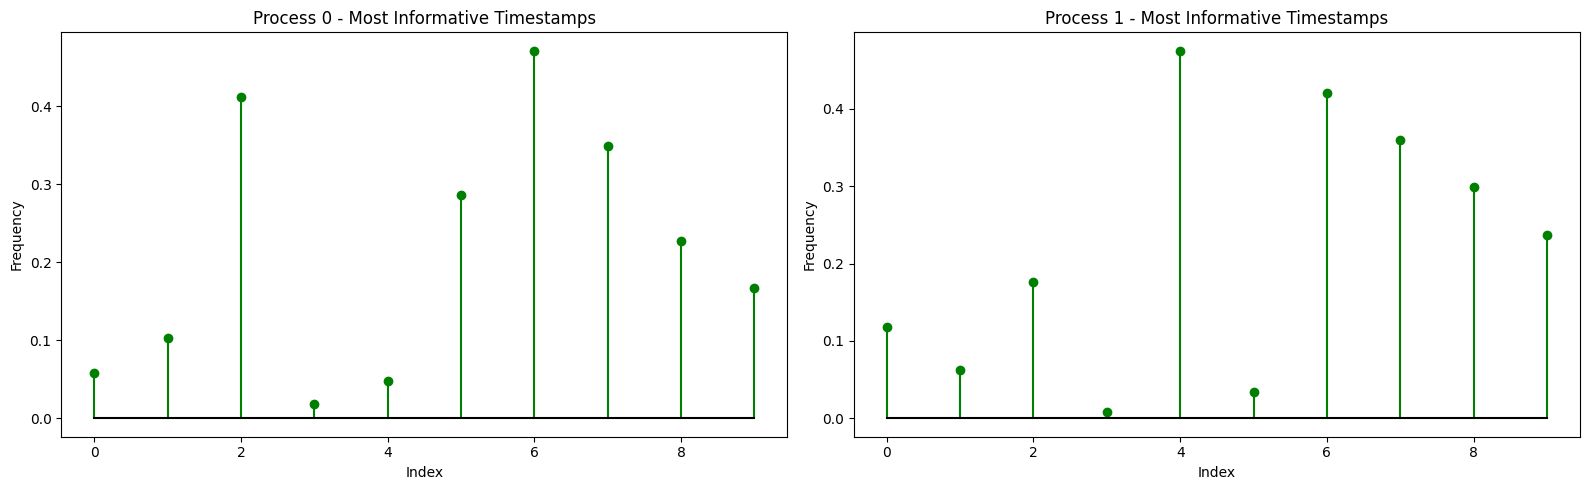

In [17]:
inducing_fig = plot_inducing_points(model)
plt.show()
plt.close(inducing_fig)

### Cluster Distance Tracking

In [19]:
def compute_cluster_distance(model):
    """Compute distance between clusters based on variational means."""
    distances = {}
    
    # Get all pairs of GPs
    for i in range(model.num_outputs):
        for j in range(i+1, model.num_outputs):
            gp_i = model.freq_model.gaussian_processes[i]
            gp_j = model.freq_model.gaussian_processes[j]
            
            mean_i = gp_i.variational_mean.detach().cpu().numpy().flatten()
            mean_j = gp_j.variational_mean.detach().cpu().numpy().flatten()
            
            distance = np.linalg.norm(mean_i - mean_j)
            distances[f'{i}-{j}'] = distance
            
    return distances

In [29]:
def compute_self_distance(current_means, previous_means):
    """Compute distance between current and previous means for each process."""
    self_distances = {}
    
    for process_idx in range(len(current_means)):
        # Get current and previous means for this process
        current = current_means[process_idx].flatten()
        previous = previous_means[process_idx].flatten()
        
        # Compute Euclidean distance
        distance = np.linalg.norm(current - previous)
        self_distances[f'process_{process_idx}'] = distance
    
    return self_distances

def update_and_track_all_distances(model, loader, num_updates=10):
    """Update model with new data and track both cluster distances and self-distances."""
    cluster_distances_history = []
    self_distances_history = []
    
    # Store all means for tracking
    all_means_history = []
    
    # Initial means and distances
    initial_means = [gp.variational_mean.detach().cpu().numpy() 
                    for gp in model.freq_model.gaussian_processes]
    all_means_history.append(initial_means.copy())
    
    initial_cluster_distances = compute_cluster_distance(model)
    cluster_distances_history.append(initial_cluster_distances)
    
    # Process batches
    iterator = iter(loader)
    for update_idx in range(num_updates):
        try:
            # Get next batch
            batch = next(iterator)
            Y_batch, labels_batch = batch
            Y_batch.squeeze_()
            X_batch = torch.linspace(0, 1, Y_batch.shape[1]).reshape(1, -1).repeat(Y_batch.shape[0], 1)
            
            # Update model
            print(f"Update {update_idx+1}/{num_updates}")
            previous_means = all_means_history[-1]
            
            with torch.no_grad():
                model.update_from_obs(X_batch.to(device), Y_batch.to(device))
            
            # Store new means
            current_means = [gp.variational_mean.detach().cpu().numpy() 
                            for gp in model.freq_model.gaussian_processes]
            all_means_history.append(current_means.copy())
            
            # Compute new distances between clusters
            new_cluster_distances = compute_cluster_distance(model)
            cluster_distances_history.append(new_cluster_distances)
            
            # Compute self-distances (how much each cluster moved)
            self_distances = compute_self_distance(current_means, previous_means)
            self_distances_history.append(self_distances)
            
            # Create visualization
            fig = plot_forecast(X_batch.to(device), Y_batch.to(device), label=0)
            plt.show()
            plt.close(fig)
            
            fig = plot_forecast(X_batch.to(device), Y_batch.to(device), label=1)
            plt.show()
            plt.close(fig)
            
        except StopIteration:
            print("Ran out of batches")
            break
    
    return cluster_distances_history, self_distances_history, all_means_history

def plot_self_distance_evolution(self_distances_history):
    """Plot how each cluster center moves after updates."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Skip first update as there's no previous state to compare
    processes = self_distances_history[0].keys()
    update_indices = range(1, len(self_distances_history) + 1)
    
    for process in processes:
        distances = [history[process] for history in self_distances_history]
        ax.plot(update_indices, distances, marker='o', label=process)
    
    ax.set_xlabel('Update Step')
    ax.set_ylabel('Distance from Previous State')
    ax.set_title('Evolution of Cluster Self-Distances (Movement)')
    ax.legend()
    ax.grid(True)
    
    return fig

def visualize_mean_evolution(all_means_history, process_idx=0):
    """Visualize how the mean vector evolves for a specific process."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Get all mean vectors for this process
    means = [means_set[process_idx].flatten() for means_set in all_means_history]
    
    # Number of inducing points (dimensions in the mean vector)
    n_dimensions = means[0].shape[0]
    
    # Plot each dimension over time
    for dim in range(n_dimensions):
        values = [mean[dim] for mean in means]
        ax.plot(range(len(means)), values, marker='o', label=f'Dim {dim}')
    
    ax.set_xlabel('Update Step')
    ax.set_ylabel('Mean Value')
    ax.set_title(f'Evolution of Mean Vector for Process {process_idx}')
    
    # If too many dimensions, don't show legend
    if n_dimensions <= 10:
        ax.legend()
    
    ax.grid(True)
    
    return fig

def plot_distance_evolution(distances_history):
    """Plot how distances between clusters evolve with updates."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for pair, _ in distances_history[0].items():
        distances = [history[pair] for history in distances_history]
        ax.plot(range(len(distances)), distances, marker='o', label=f'Classes {pair}')
    
    ax.set_xlabel('Update Step')
    ax.set_ylabel('Distance')
    ax.set_title('Evolution of Cluster Distances')
    ax.legend()
    ax.grid(True)
    
    return fig

Update 1/10


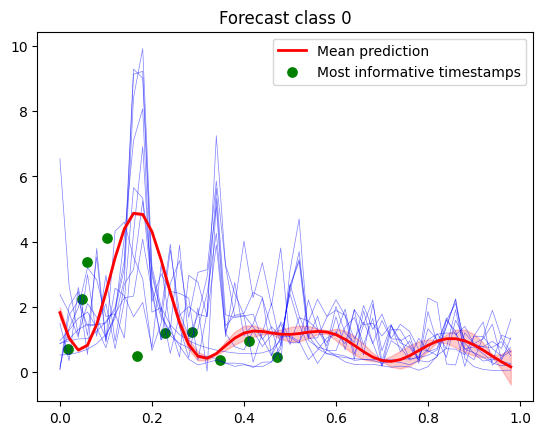

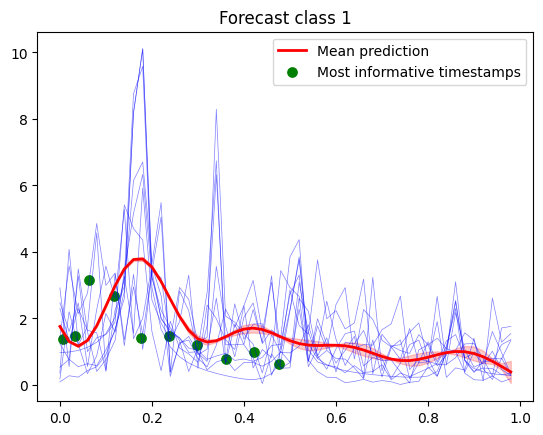

Update 2/10


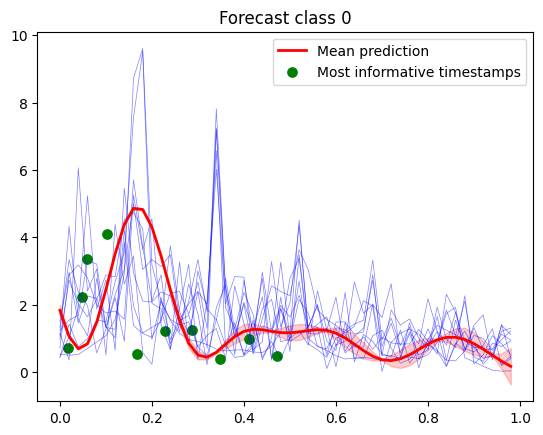

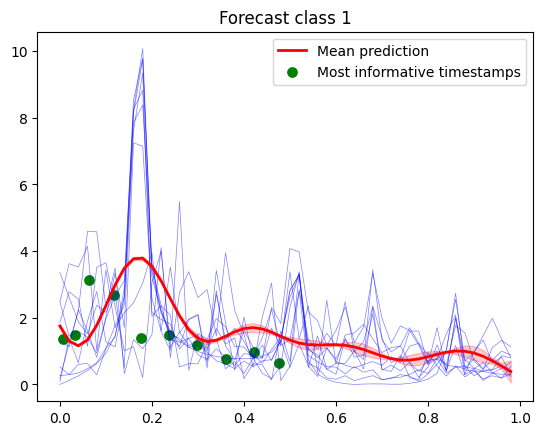

Update 3/10


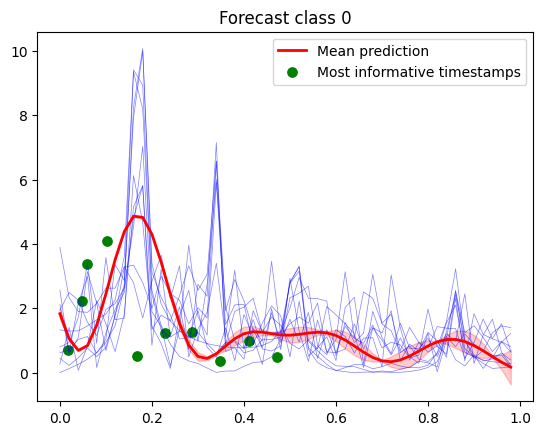

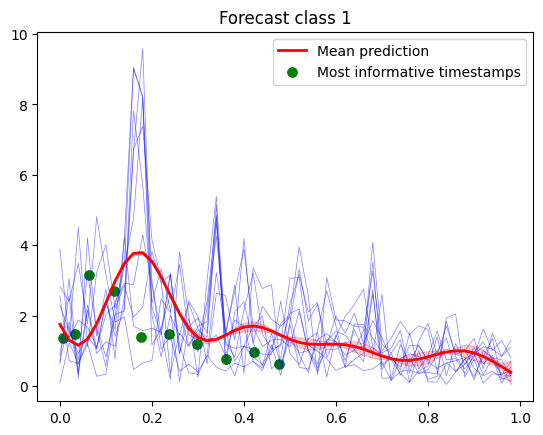

Update 4/10


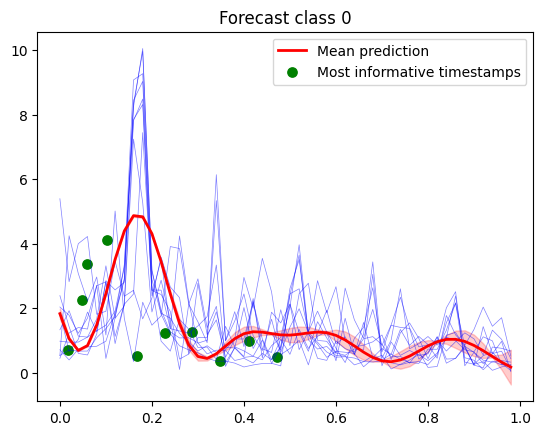

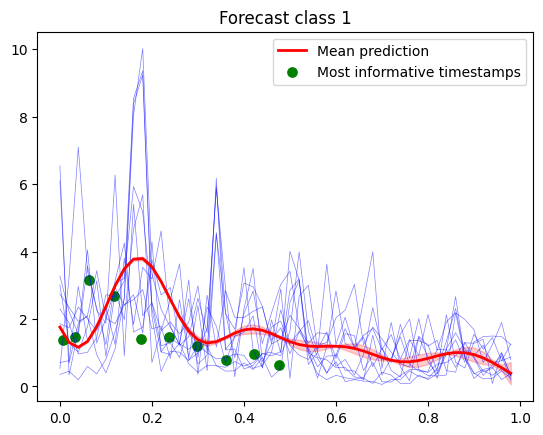

Update 5/10


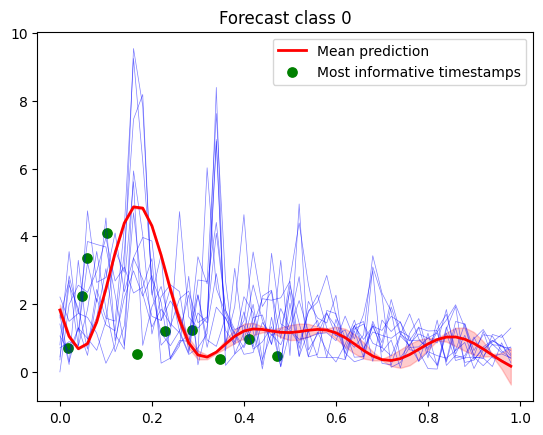

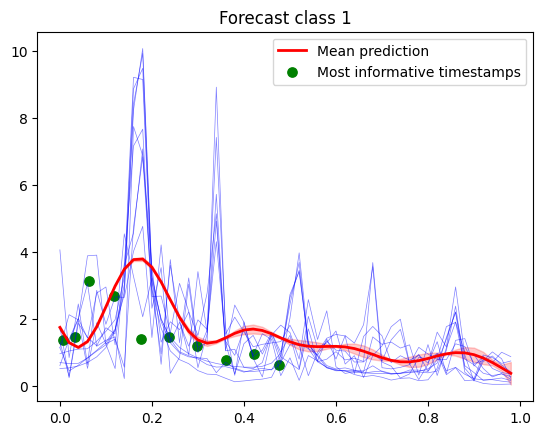

Update 6/10


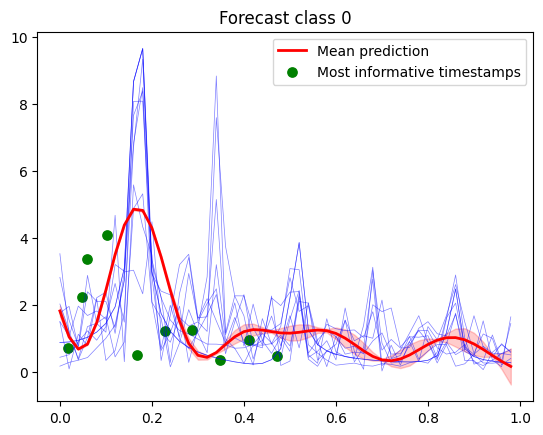

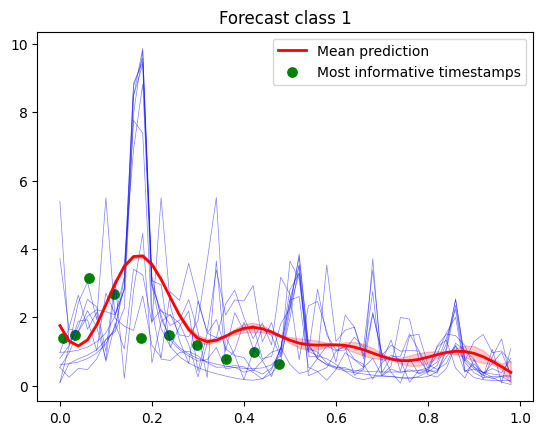

Update 7/10


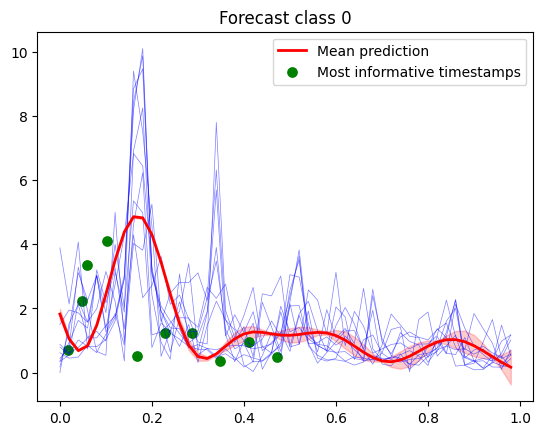

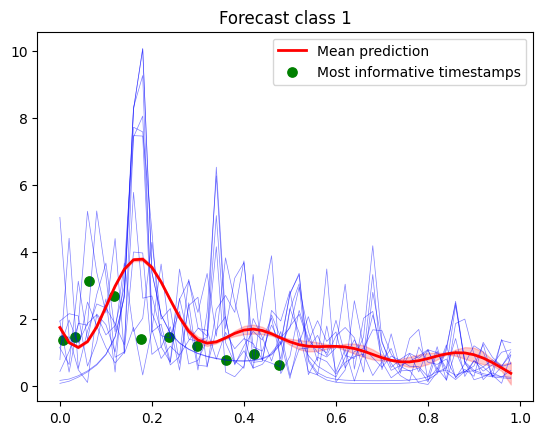

Update 8/10


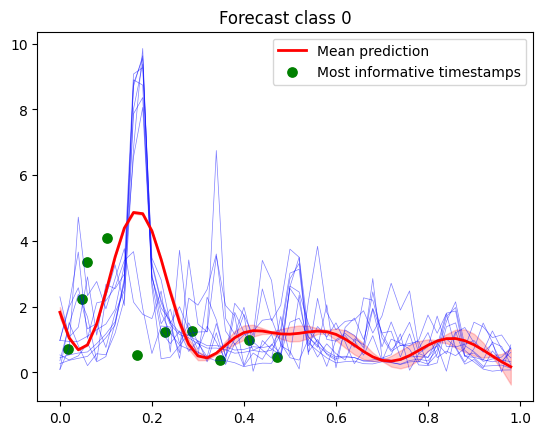

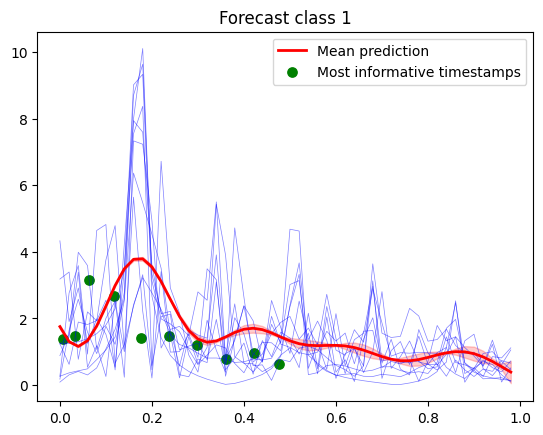

Update 9/10


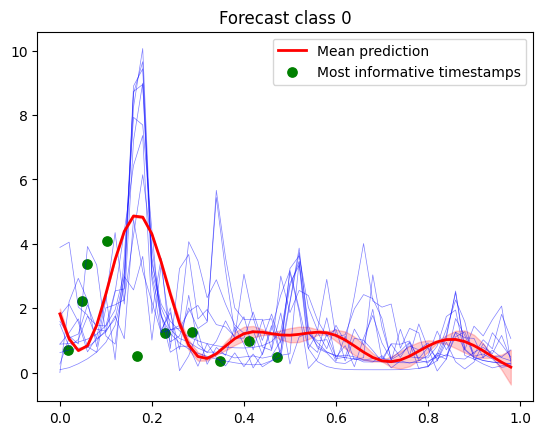

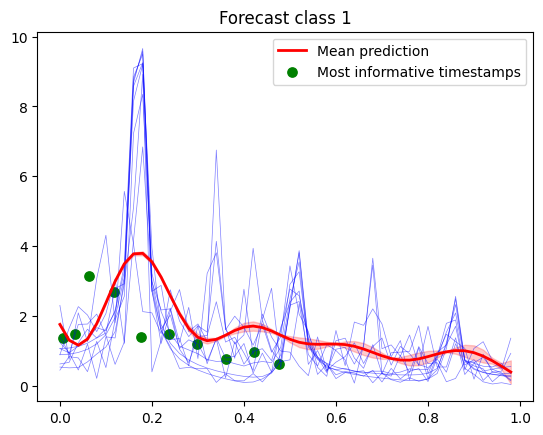

Update 10/10


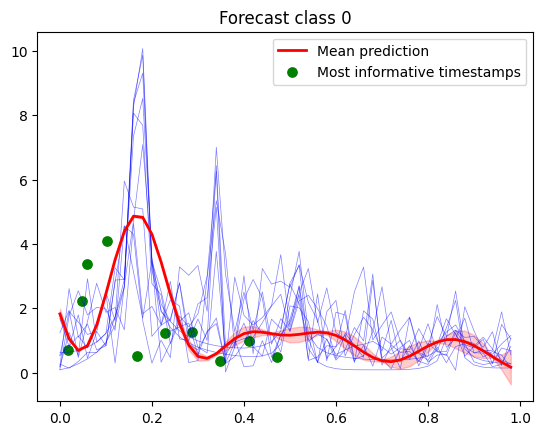

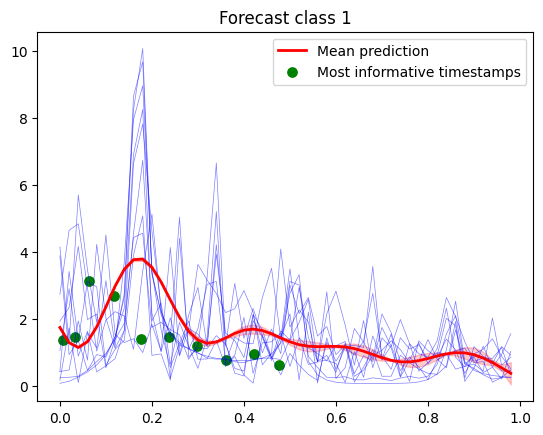

Cluster distances history:


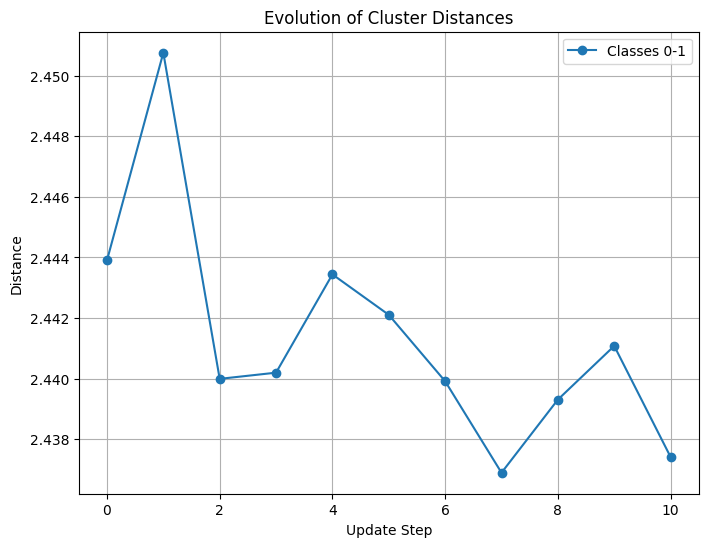

Self distances history:


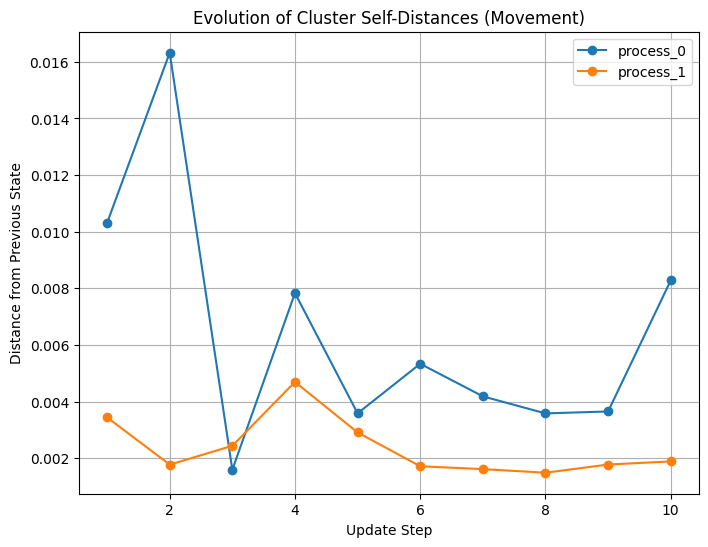

Mean evolution for process 0:


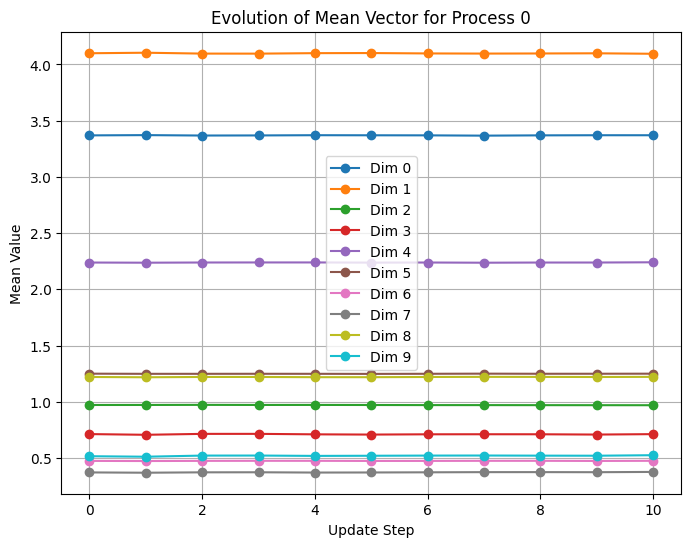

Mean evolution for process 1:


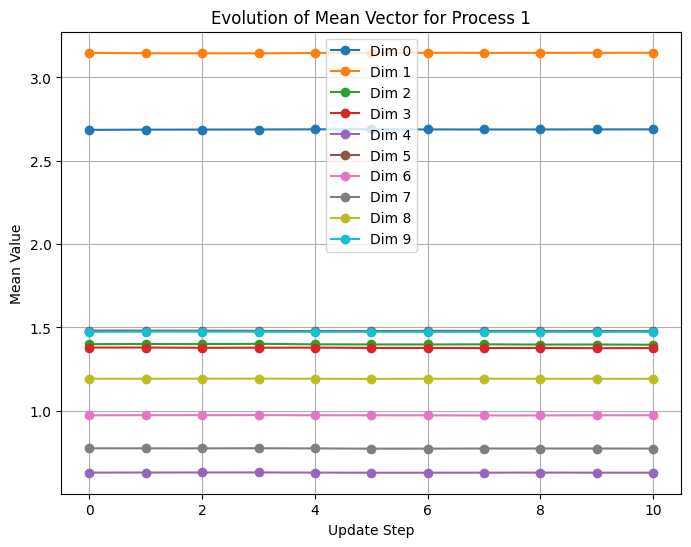

In [31]:
update_loader = DataLoader(row_dataset, batch_size=400, shuffle=True, collate_fn=row_collate_fn)

cluster_distances_history, self_distances_history, all_means_history = update_and_track_all_distances(
    model, update_loader, num_updates=10)

cluster_distance_fig = plot_distance_evolution(cluster_distances_history)
print("Cluster distances history:")
plt.show()

self_distance_fig = plot_self_distance_evolution(self_distances_history)
print("Self distances history:")
plt.show()

for idx in range(model.num_outputs):
    mean_evol_fig = visualize_mean_evolution(all_means_history, process_idx=idx)
    print(f"Mean evolution for process {idx}:")
    plt.show()